#Exemplo de técnicas de feature selection em Python com o dataset Wine

In [7]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine # para importar o dataset wine
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada

from sklearn.ensemble import ExtraTreesClassifier # ExtraTrees, para a Importância de Atributos
from sklearn.feature_selection import SelectKBest # para a Seleção Univariada
from sklearn.feature_selection import f_classif # para o teste ANOVA da Seleção Univariada
from sklearn.feature_selection import RFE # para a Eliminação Recursiva de Atributos
from sklearn.linear_model import LogisticRegression # Regressão Logística, para a Eliminação Recursiva de Atributos



In [8]:
# Carga do dataset
wine = load_wine()
dataset = pd.DataFrame(wine.data, columns=wine.feature_names) # conversão para dataframe
dataset['target'] = wine.target # adição da coluna target

dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
# Preparação dos dados

# Separação em bases de treino e teste (holdout)
array = dataset.values
X = array[:,0:13] # atributos
y = array[:,13] # classe (target)

In [10]:
# SelectKBest

# Seleção de atributos com SelectKBest
best_var = SelectKBest(score_func=f_classif, k=4)

# Executa a função de pontuação em (X, y) e obtém os atributos selecionados
fit = best_var.fit(X, y)

# Reduz X para os atributos selecionados
features = fit.transform(X)

# Resultados
print('\nNúmero original de atributos:', X.shape[1])
print('\nNúmero reduzido de atributos:', features.shape[1])

# Exibe os atributos orginais
print("\nAtributos Originais:", dataset.columns[0:13])

# Exibe as pontuações de cada atributos e os 4 escolhidas (com as pontuações mais altas)
np.set_printoptions(precision=3) # 3 casas decimais
print("\nScores dos Atributos Originais:", fit.scores_)
print("\nAtributos Selecionados:", best_var.get_feature_names_out(input_features=dataset.columns[0:13]))


Número original de atributos: 13

Número reduzido de atributos: 4

Atributos Originais: Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

Scores dos Atributos Originais: [135.078  36.943  13.313  35.772  12.43   93.733 233.926  27.575  30.271
 120.664 101.317 189.972 207.92 ]

Atributos Selecionados: ['alcohol' 'flavanoids' 'od280/od315_of_diluted_wines' 'proline']


In [11]:
# Eliminação Recursiva de Atributos

# Criação do modelo
modelo = LogisticRegression(max_iter=200)

# Eliminação Recursiva de Atributos
rfe = RFE(modelo, n_features_to_select=4)
fit = rfe.fit(X, y)

# Print dos resultados
print("Atributos Originais:", dataset.columns[0:13])

# Exibe os atributos selecionados (marcados como True em "Atributos Selecionados"
# e com valor 1 em "Ranking dos Atributos")
print("\nAtributos Selecionados: %s" % fit.support_)
print("\nRanking de atributos: %s" % fit.ranking_)
print("\nQtd de melhores Atributos: %d" % fit.n_features_)
print("\nNomes dos Atributos Selecionados: %s" % fit.get_feature_names_out(input_features=dataset.columns[0:13]))

Atributos Originais: Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

Atributos Selecionados: [ True False  True False False False  True False False False False  True
 False]

Ranking de atributos: [ 1  5  1  7  9  3  1  8  6  2  4  1 10]

Qtd de melhores Atributos: 4

Nomes dos Atributos Selecionados: ['alcohol' 'ash' 'flavanoids' 'od280/od315_of_diluted_wines']


In [12]:
# Importância de Atributos com ExtraTrees

# Criação do modelo para seleção de atributos
modelo = ExtraTreesClassifier(n_estimators=100)
modelo.fit(X,y)

# Exibe os atributos orginais
print("\nAtributos Originais:", dataset.columns[0:13])

# Exibe a pontuação de importância para cada atributo (quanto maior a pontuação, mais importante é o atributo).
print(modelo.feature_importances_)


Atributos Originais: Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')
[0.123 0.039 0.029 0.039 0.035 0.061 0.137 0.032 0.025 0.123 0.076 0.131
 0.15 ]


#Exempplo prático de modelos


In [13]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [14]:
# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/tatianaesc/datascience/main/diabetes.csv"

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')

# Mostra as primeiras linhas do dataset
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = dataset.values
X = array[:,0:8]
y = array[:,8]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

LR: 0.762427 (0.057485)
KNN: 0.711978 (0.058934)
CART: 0.702010 (0.063448)
NB: 0.746060 (0.051145)
SVM: 0.749418 (0.040958)
Bagging: 0.760814 (0.046503)
RF: 0.772263 (0.048493)
ET: 0.756002 (0.066055)
Ada: 0.759281 (0.055599)
GB: 0.752618 (0.054653)
Voting: 0.762507 (0.061246)


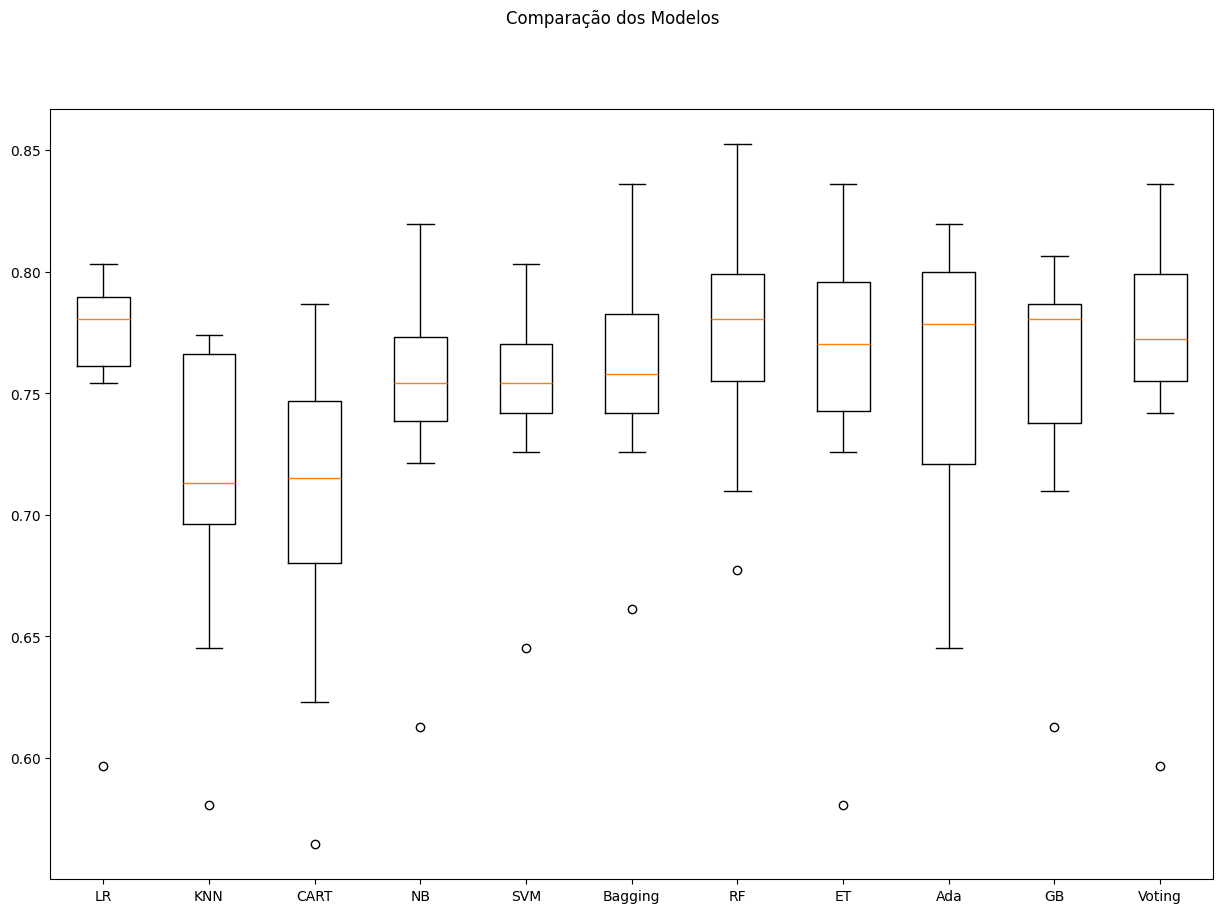

In [19]:
np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

LR-orig: 0.762 (0.057)
KNN-orig: 0.712 (0.059)
CART-orig: 0.702 (0.063)
NB-orig: 0.746 (0.051)
SVM-orig: 0.749 (0.041)
Bag-orig: 0.761 (0.047)
RF-orig: 0.772 (0.048)
ET-orig: 0.756 (0.066)
Ada-orig: 0.759 (0.056)
GB-orig: 0.753 (0.055)
Vot-orig: 0.763 (0.061)
LR-padr: 0.762 (0.057)
KNN-padr: 0.727 (0.069)
CART-padr: 0.699 (0.048)
NB-padr: 0.746 (0.051)
SVM-padr: 0.763 (0.053)
Bag-padr: 0.772 (0.045)
RF-padr: 0.751 (0.048)
ET-padr: 0.776 (0.061)
Ada-padr: 0.759 (0.056)
GB-padr: 0.749 (0.059)
Vot-padr: 0.774 (0.047)
LR-norm: 0.753 (0.046)
KNN-norm: 0.725 (0.083)
CART-norm: 0.697 (0.069)
NB-norm: 0.746 (0.051)
SVM-norm: 0.772 (0.054)
Bag-norm: 0.766 (0.050)
RF-norm: 0.776 (0.043)
ET-norm: 0.767 (0.059)
Ada-norm: 0.759 (0.056)
GB-norm: 0.751 (0.058)
Vot-norm: 0.774 (0.049)


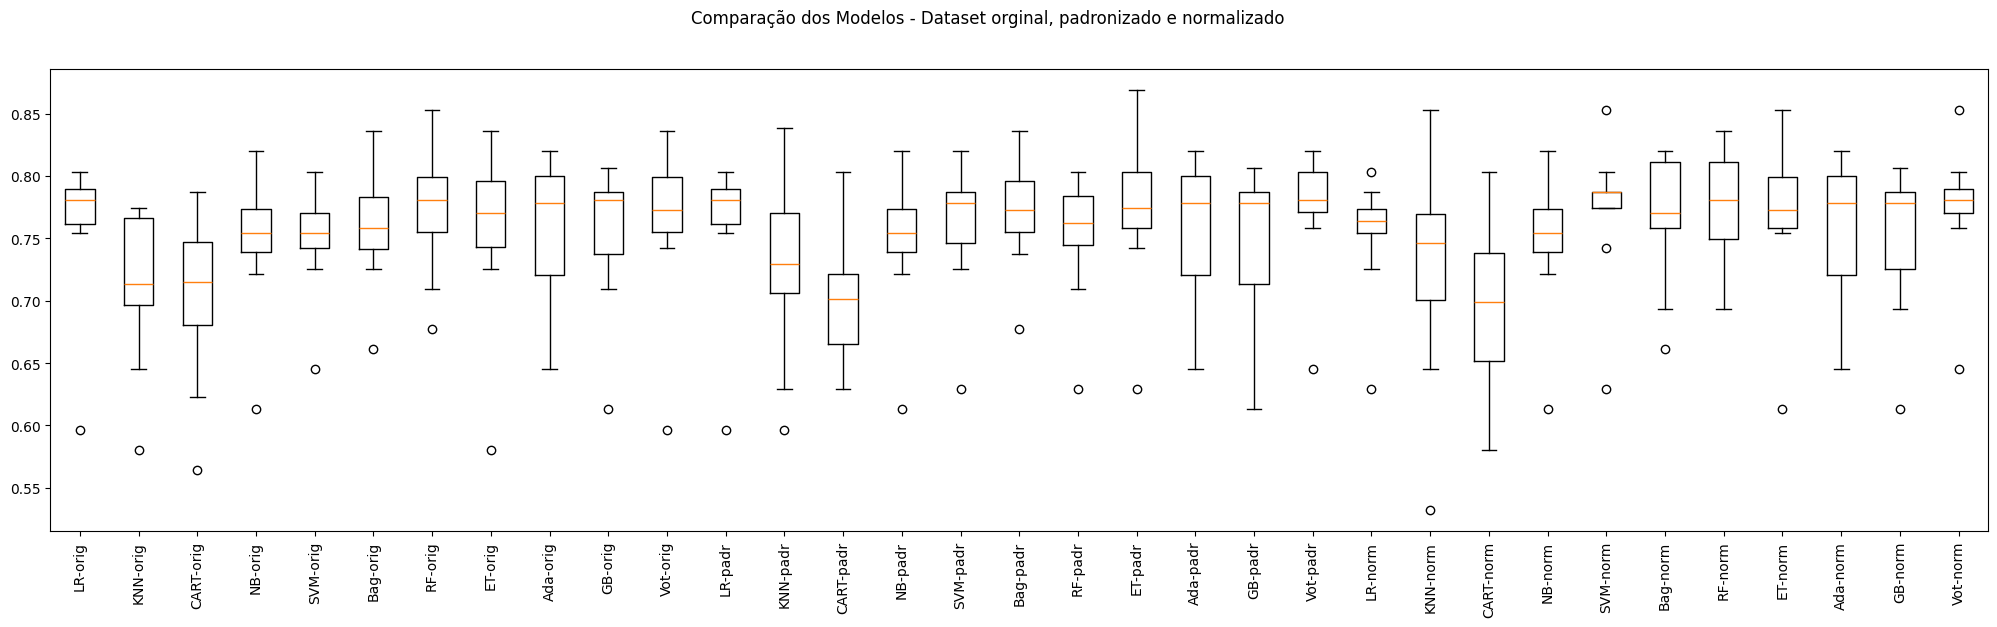

In [21]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bag', BaggingClassifier(base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

In [22]:
# Tuning do KNN

np.random.seed(7) # definindo uma semente global para este bloco

pipelines = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('knn-orig', Pipeline(steps=[knn])))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Sem tratamento de missings: knn-orig - Melhor: 0.757615 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 17}
Sem tratamento de missings: knn-padr - Melhor: 0.757509 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 19}
Sem tratamento de missings: knn-norm - Melhor: 0.759228 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 13}


In [23]:
# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
scaler = StandardScaler().fit(X_train) # ajuste do scaler com o conjunto de treino
rescaledX = scaler.transform(X_train) # aplicação da padronização no conjunto de treino
model = LogisticRegression(max_iter=200)
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test) # aplicação da padronização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(accuracy_score(y_test, predictions))

0.7727272727272727


In [24]:
# Preparação do modelo com TODO o dataset
scaler = StandardScaler().fit(X) # ajuste do scaler com TODO o dataset
rescaledX = scaler.transform(X) # aplicação da padronização com TODO o dataset
model.fit(rescaledX, y)

LogisticRegression(max_iter=200)

In [25]:
# Novos dados - não sabemos a classe!
data = {'preg':  [1, 9, 5],
        'plas': [90, 100, 110],
        'pres': [50, 60, 50],
        'skin': [30, 30, 30],
        'test': [100, 100, 100],
        'mass': [20.0, 30.0, 40.0],
        'pedi': [1.0, 2.0, 1.0],
        'age': [15, 40, 40],
        }

atributos = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
entrada = pd.DataFrame(data, columns=atributos)

array_entrada = entrada.values
X_entrada = array_entrada[:,0:8].astype(float)

# Padronização nos dados de entrada usando o scaler utilizado em X
rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)

[[-0.845 -0.967 -0.988  0.594  0.175 -1.522  1.595 -1.552]
 [ 1.531 -0.654 -0.471  0.594  0.175 -0.253  4.615  0.575]
 [ 0.343 -0.341 -0.988  0.594  0.175  1.016  1.595  0.575]]


In [26]:
# Predição de classes dos dados de entrada
saidas = model.predict(rescaledEntradaX)
print(saidas)

[0. 1. 1.]


#Outros modelos

DATASET DIABETES
Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Distribuição das classes:
Outcome
0    500
1    268
Name: count, dtype: int64

1. CLASSIFICAÇÃO COM CUSTO SENSÍVEL (class_weight)

Pesos calculados para as classes: {np.float64(0.0): np.float64(0.7675), np.float64(1.0): np.float64(1.4345794392523366)}
Classe 0 (não dia

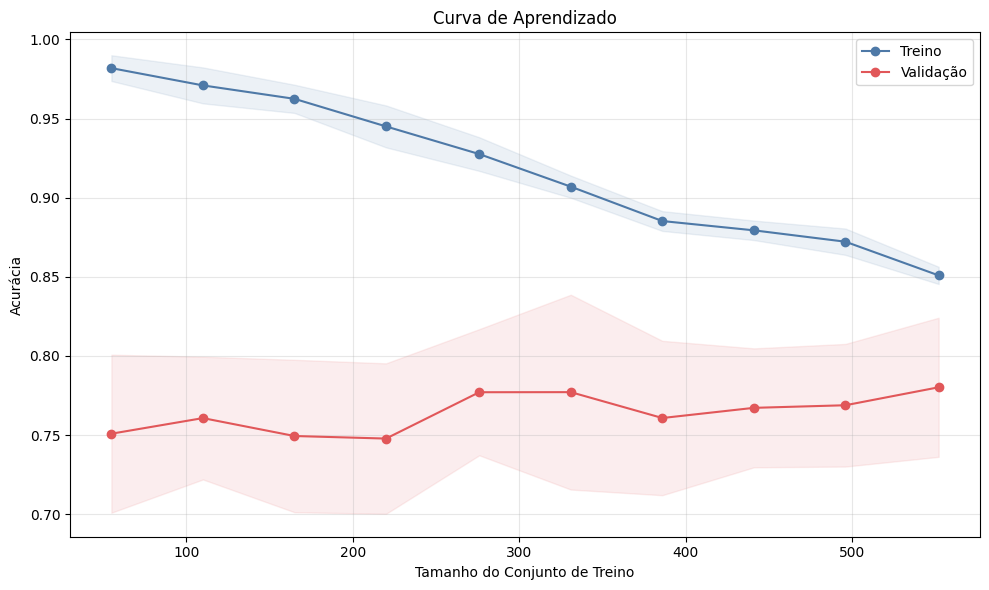


8. TÉCNICAS DE ENSEMBLE AVANÇADAS

📊 Stacking Classifier:
Stacking Classifier: Acurácia = 0.7851 (±0.0582)

📊 Voting Classifier com pesos personalizados:
Voting (soft, pesos=1,2,2): Acurácia = 0.7607

9. ANÁLISE DE IMPORTÂNCIA DAS FEATURES


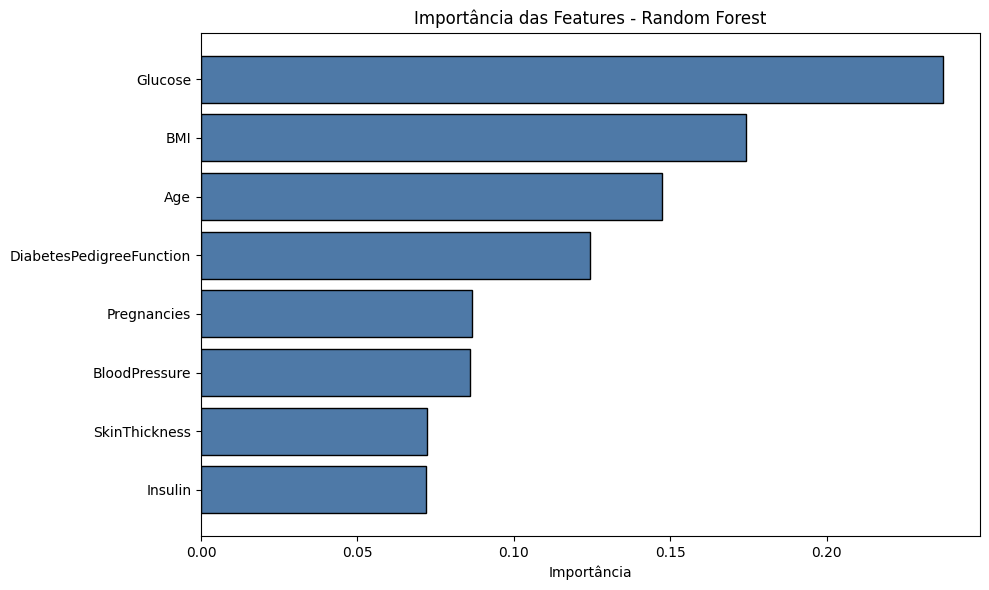


Ranking de importância das features:
  1. Glucose: 0.2372
  2. BMI: 0.1742
  3. Age: 0.1475
  4. DiabetesPedigreeFunction: 0.1243
  5. Pregnancies: 0.0866
  6. BloodPressure: 0.0859
  7. SkinThickness: 0.0724
  8. Insulin: 0.0718

10. AVALIAÇÃO FINAL DO MELHOR MODELO


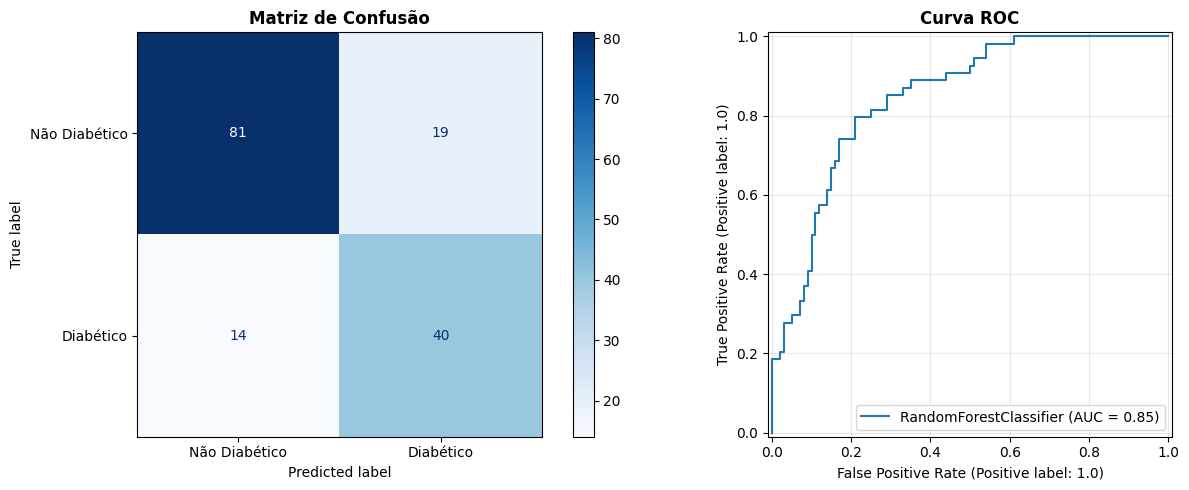


📋 Classification Report:
               precision    recall  f1-score   support

Não Diabético       0.85      0.81      0.83       100
    Diabético       0.68      0.74      0.71        54

     accuracy                           0.79       154
    macro avg       0.77      0.78      0.77       154
 weighted avg       0.79      0.79      0.79       154


✅ RECURSOS AVANÇADOS APLICADOS COM SUCESSO


In [28]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import cohen_kappa_score, balanced_accuracy_score, average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import plot_tree

# Modelos base
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Alternativas para classificação com custo sensível (nativas do sklearn)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/tatianaesc/datascience/main/diabetes.csv"

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')

print("="*80)
print("DATASET DIABETES")
print("="*80)
print(f"Shape: {dataset.shape}")
print(dataset.head())
print(f"\nDistribuição das classes:\n{dataset['Outcome'].value_counts()}")

# Separação em conjuntos de treino e teste
test_size = 0.20
seed = 7
array = dataset.values
X = array[:,0:8]
y = array[:,8]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                    shuffle=True, random_state=seed,
                                                    stratify=y)

# Configurações da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

np.random.seed(7)

print("\n" + "="*80)
print("1. CLASSIFICAÇÃO COM CUSTO SENSÍVEL (class_weight)")
print("="*80)

# ============================================
# 1. CLASSIFICAÇÃO COM PESOS DIFERENCIADOS (CUSTO SENSÍVEL)
# ============================================

# Calculando pesos para as classes
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, class_weights))

print(f"\nPesos calculados para as classes: {weight_dict}")
print(f"Classe 0 (não diabético): {weight_dict[0]:.2f}")
print(f"Classe 1 (diabético): {weight_dict[1]:.2f}")

# Modelos com class_weight
models_with_weights = [
    ('Logistic Regression (balanced)', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)),
    ('Logistic Regression (custom)', LogisticRegression(class_weight=weight_dict, max_iter=1000, random_state=seed)),
    ('SVM (balanced)', SVC(class_weight='balanced', random_state=seed)),
    ('SVM (custom)', SVC(class_weight=weight_dict, random_state=seed)),
    ('Random Forest (balanced)', RandomForestClassifier(class_weight='balanced', random_state=seed)),
    ('Random Forest (custom)', RandomForestClassifier(class_weight=weight_dict, random_state=seed))
]

print("\n📊 Comparação de modelos com pesos de classe:")
for name, model in models_with_weights:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    print(f"{name:35} - Acurácia: {cv_results.mean():.4f} (±{cv_results.std():.4f})")

# ============================================
# 2. AVALIAÇÃO COM MÉTRICAS PARA DADOS DESBALANCEADOS
# ============================================

print("\n" + "="*80)
print("2. MÉTRICAS PARA DADOS DESBALANCEADOS")
print("="*80)

# Usando o melhor modelo com pesos
best_weighted_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)
best_weighted_model.fit(X_train, y_train)
y_pred = best_weighted_model.predict(X_test)
y_pred_proba = best_weighted_model.predict_proba(X_test)[:, 1]

print(f"\n✅ Modelo: Logistic Regression com class_weight='balanced'")
print(f"✅ Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"✅ Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"✅ Recall (Sensibilidade): {recall_score(y_test, y_pred):.4f}")
print(f"✅ F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"✅ Matthews CC: {matthews_corrcoef(y_test, y_pred):.4f}")

# ============================================
# 3. TÉCNICAS AVANÇADAS DE PRÉ-PROCESSAMENTO
# ============================================

print("\n" + "="*80)
print("3. TÉCNICAS AVANÇADAS DE PRÉ-PROCESSAMENTO")
print("="*80)

# Diferentes tipos de escalonamento
print("\n📊 Comparação de diferentes técnicas de escalonamento:")

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'PowerTransformer (Yeo-Johnson)': PowerTransformer(method='yeo-johnson')
}

scaler_results = []

for name, scaler in scalers.items():
    pipeline = Pipeline([('scaler', scaler),
                         ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed))])
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring=scoring)
    print(f"{name:35} - Acurácia: {cv_results.mean():.4f} (±{cv_results.std():.4f})")

# ============================================
# 4. FEATURE SELECTION AVANÇADA
# ============================================

print("\n" + "="*80)
print("4. TÉCNICAS AVANÇADAS DE SELEÇÃO DE FEATURES")
print("="*80)

# Seleção por variância
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X_train)
print(f"\n✅ VarianceThreshold: {X_train.shape[1]} -> {X_selected.shape[1]} features")

# SelectKBest com diferentes k
print("\n📊 SelectKBest (f_classif):")
for k in [3, 4, 5, 6, 7, 8]:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_selected = selector.fit_transform(X_train, y_train)
    pipeline = Pipeline([('scaler', StandardScaler()),
                         ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed))])
    cv_results = cross_val_score(pipeline, X_selected, y_train, cv=kfold, scoring=scoring)
    print(f"  k={k}: Acurácia = {cv_results.mean():.4f}")

# RFE (Recursive Feature Elimination)
print("\n📊 RFE (Recursive Feature Elimination):")
feature_names = dataset.columns[:-1]
for n_features in [3, 4, 5, 6]:
    estimator = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)
    selector = RFE(estimator, n_features_to_select=n_features)
    X_selected = selector.fit_transform(X_train, y_train)
    pipeline = Pipeline([('scaler', StandardScaler()),
                         ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed))])
    cv_results = cross_val_score(pipeline, X_selected, y_train, cv=kfold, scoring=scoring)
    print(f"  n={n_features}: Acurácia = {cv_results.mean():.4f}")
    print(f"    Features: {feature_names[selector.support_].tolist()}")

# ============================================
# 5. REDUÇÃO DE DIMENSIONALIDADE
# ============================================

print("\n" + "="*80)
print("5. REDUÇÃO DE DIMENSIONALIDADE")
print("="*80)

# PCA
print("\n📊 PCA (Principal Component Analysis):")
for n in [2, 3, 4, 5, 6, 7, 8]:
    pipeline = Pipeline([('scaler', StandardScaler()),
                         ('pca', PCA(n_components=n)),
                         ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed))])
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring=scoring)
    print(f"  n={n}: Acurácia = {cv_results.mean():.4f}")

# ============================================
# 6. OTIMIZAÇÃO DE HIPERPARÂMETROS
# ============================================

print("\n" + "="*80)
print("6. OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("="*80)

# GridSearchCV para Random Forest
print("\n🔍 GridSearchCV para Random Forest:")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=seed)
grid_search = GridSearchCV(rf, param_grid_rf, cv=kfold, scoring=scoring, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Melhor acurácia: {grid_search.best_score_:.4f}")
print(f"Melhores parâmetros: {grid_search.best_params_}")

# RandomizedSearchCV para Gradient Boosting
print("\n🔍 RandomizedSearchCV para Gradient Boosting:")
param_dist_gb = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=seed)
random_search = RandomizedSearchCV(gb, param_dist_gb, n_iter=20, cv=kfold,
                                    scoring=scoring, random_state=seed, n_jobs=-1)
random_search.fit(X_train, y_train)
print(f"Melhor acurácia: {random_search.best_score_:.4f}")
print(f"Melhores parâmetros: {random_search.best_params_}")

# ============================================
# 7. CURVAS DE APRENDIZADO
# ============================================

print("\n" + "="*80)
print("7. CURVAS DE APRENDIZADO")
print("="*80)

best_model = grid_search.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=kfold, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#4e79a7', label='Treino')
plt.plot(train_sizes, test_mean, 'o-', color='#e15759', label='Validação')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#4e79a7')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#e15759')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('Acurácia')
plt.title('Curva de Aprendizado')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 8. ENSEMBLES AVANÇADOS
# ============================================

print("\n" + "="*80)
print("8. TÉCNICAS DE ENSEMBLE AVANÇADAS")
print("="*80)

# Stacking Classifier
print("\n📊 Stacking Classifier:")

base_learners = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)),
    ('rf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=seed)),
    ('gb', GradientBoostingClassifier(random_state=seed))
]

stacking = StackingClassifier(estimators=base_learners,
                              final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed),
                              cv=5)

cv_results = cross_val_score(stacking, X_train, y_train, cv=kfold, scoring=scoring)
print(f"Stacking Classifier: Acurácia = {cv_results.mean():.4f} (±{cv_results.std():.4f})")

# Voting Classifier com pesos
print("\n📊 Voting Classifier com pesos personalizados:")
voting_weighted = VotingClassifier(estimators=base_learners, voting='soft', weights=[1, 2, 2])
cv_results = cross_val_score(voting_weighted, X_train, y_train, cv=kfold, scoring=scoring)
print(f"Voting (soft, pesos=1,2,2): Acurácia = {cv_results.mean():.4f}")

# ============================================
# 9. IMPORTÂNCIA DAS FEATURES
# ============================================

print("\n" + "="*80)
print("9. ANÁLISE DE IMPORTÂNCIA DAS FEATURES")
print("="*80)

# Treinar um Random Forest para análise de importância
rf_importance = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=seed)
rf_importance.fit(X_train, y_train)

importances = rf_importance.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = dataset.columns[:-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='#4e79a7', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importância')
plt.title('Importância das Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nRanking de importância das features:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# ============================================
# 10. MATRIZ DE CONFUSÃO E RELATÓRIO DE CLASSIFICAÇÃO
# ============================================

print("\n" + "="*80)
print("10. AVALIAÇÃO FINAL DO MELHOR MODELO")
print("="*80)

# Treinar o melhor modelo com todo o conjunto de treino
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                       display_labels=['Não Diabético', 'Diabético'],
                                       cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Relatório de classificação
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Não Diabético', 'Diabético']))

print("\n" + "="*80)
print("✅ RECURSOS AVANÇADOS APLICADOS COM SUCESSO")
print("="*80)

## 📋 TABELA DE VANTAGENS E DESVANTAGENS

### 1. **Técnicas de Pré-processamento**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **StandardScaler** | • Média 0, desvio 1<br>• Preserva outliers<br>• Bom para SVM, Regressão | • Sensível a outliers | Algoritmos que assumem distribuição normal |
| **MinMaxScaler** | • Escala [0,1]<br>• Preserva zeros<br>• Bom para Redes Neurais | • Afetado por outliers | Dados com limites conhecidos |
| **RobustScaler** | • Robusto a outliers<br>• Usa mediana e IQR | • Não preserva forma da distribuição | Dados com muitos outliers |
| **PowerTransformer** | • Torna dados mais normais<br>• Reduz assimetria | • Mais lento<br>• Pode falhar com zeros | Dados com distribuição assimétrica |
| **PolynomialFeatures** | • Captura interações não-lineares<br>• Aumenta capacidade do modelo | • Aumenta dimensionalidade<br>• Risco de overfitting | Relações não-lineares entre features |
| **Imputação (Mean/Median)** | • Simples, rápida<br>• Preserva tamanho do dataset | • Distorce distribuição<br>• Reduz variabilidade | Poucos valores ausentes |

### 2. **Seleção de Features**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **VarianceThreshold** | • Remove features constantes<br>• Muito rápido | • Não considera relação com target | Features com pouca variação |
| **SelectKBest (f_classif)** | • Rápido, univariado<br>• Bom para features independentes | • Ignora interações entre features | Primeira filtragem |
| **RFE (Recursive Elimination)** | • Considera interações<br>• Otimiza para o modelo | • Lento para muitas features<br>• Sensível ao modelo base | Número moderado de features |
| **SelectFromModel** | • Usa importância do modelo<br>• Considera interações | • Dependente do modelo escolhido | Usar com Random Forest, Lasso |

### 3. **Redução de Dimensionalidade**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **PCA** | • Linear, rápido<br>• Reduz correlações<br>• Melhora performance | • Perde interpretabilidade<br>• Assume linearidade | Features correlacionadas |
| **Kernel PCA** | • Captura não-linearidades<br>• Flexível | • Mais lento<br>• Parâmetros críticos | Dados com estrutura não-linear |
| **t-SNE** | • Ótimo para visualização<br>• Preserva vizinhança | • Muito lento<br>• Não determinístico | Visualização (apenas) |

### 4. **Otimização de Hiperparâmetros**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **GridSearchCV** | • Exaustivo<br>• Encontra ótimo global | • Muito lento<br>• Não escala bem | Espaço de busca pequeno |
| **RandomizedSearchCV** | • Mais rápido que Grid<br>• Explora mais combinações | • Não garante ótimo global | Espaço de busca grande |
| **HalvingGridSearch** | • Mais eficiente<br>• Elimina opções ruins cedo | • Mais complexo | Recursos computacionais limitados |

### 5. **Métricas de Avaliação Avançadas**

| Métrica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **ROC-AUC** | • Avalia separação de classes<br>• Independente do limiar | • Sensível a desbalanceamento | Avaliar poder discriminatório |
| **Matthews CCC** | • Balanceado<br>• Usa matriz de confusão completa | • Menos intuitivo | Classes desbalanceadas |
| **Cohen's Kappa** | • Ajusta acerto ao acaso<br>• Bom para dados desbalanceados | • Pode ser baixo mesmo com boa acurácia | Comparar com baseline |
| **Balanced Accuracy** | • Média das acurácias por classe<br>• Robusto a desbalanceamento | • Perde informação de erro | Classes desbalanceadas |

### 6. **Ensembles Avançados**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **Stacking** | • Aprende melhor combinação<br>• Reduz viés e variância | • Mais lento<br>• Pode overfitar | Máxima performance |
| **Voting (soft)** | • Usa probabilidades<br>• Suave | • Requer modelos calibrados | Probabilidades bem calibradas |
| **Voting (hard)** | • Simples, rápido<br>• Funciona com qualquer modelo | • Ignora confiança das predições | Ensembles simples |
| **CalibratedClassifier** | • Melhora probabilidades<br>• Útil para SVM | • Adiciona overhead | Quando probabilidades são importantes |

### 7. **Análise de Curvas**

| Técnica | Vantagens | Desvantagens | Melhor para |
|---------|-----------|--------------|-------------|
| **Learning Curve** | • Detecta over/underfitting<br>• Avalia necessidade de mais dados | • Computacionalmente intensivo | Diagnosticar viés/variância |
| **Validation Curve** | • Otimiza hiperparâmetros<br>• Visualiza trade-offs | • Analisa um parâmetro por vez | Escolha de hiperparâmetros |

## 🎯 **RECOMENDAÇÕES POR CENÁRIO**

| Cenário | Técnicas Recomendadas | Motivo |
|---------|----------------------|--------|
| **Poucos dados (<1000)** | • Learning Curves<br>• Validação Cruzada com muitas folds<br>• Modelos simples | Evitar overfitting |
| **Muitos dados (>100k)** | • RandomizedSearchCV<br>• PCA para redução<br>• MinMaxScaler | Velocidade e escalabilidade |
| **Features correlacionadas** | • PCA<br>• Ridge/Lasso<br>• RFE | Reduzir multicolinearidade |
| **Dados desbalanceados** | • Balanced Accuracy<br>• Matthews CC<br>• Class weights | Avaliação justa |
| **Máxima acurácia** | • Stacking<br>• XGBoost/LightGBM<br>• Otimização extensiva | Estado da arte |
| **Interpretabilidade** | • Feature importance<br>• Partial dependence<br>• Modelos simples (árvores) | Explicabilidade |
| **Produção (tempo real)** | • Modelos simples<br>• PCA<br>• Sem validação pesada | Latência |


## 💡 **CONCLUSÃO**

Os recursos avançados apresentados permitem:

1. **Melhorar a qualidade dos dados** através de pré-processamento adequado
2. **Reduzir dimensionalidade** para aumentar eficiência
3. **Otimizar hiperparâmetros** para maximizar performance
4. **Avaliar modelos com múltiplas métricas** para diagnóstico completo
5. **Combinar modelos** via ensembles para maior robustez
6. **Diagnosticar problemas** através de curvas de aprendizado